In [1]:
from pathlib import Path
from copy import deepcopy

import torch
import random
import numpy as np
import pandas as pd

from src.utils import set_seed, print_runtime, create_folder, get_folder_size, print_message, pprint
from src.data.config import data_config
from src.data.sampler import DatasetSampler
from src.data.loader import HuggingFaceDatasetLoader
from src.data.canonical import (
    CanonicalDatasetBuilder,
    CanonicalDatasetVisualizer,
    CanonicalDatasetSerializer,
)
from src.config import global_config
from src.data.config import data_config

In [2]:
GLOBAL_CONFIG = deepcopy(global_config)

DATA_CONFIG = deepcopy(data_config)

print(GLOBAL_CONFIG)

{'seed': 42, 'device': device(type='mps'), 'data': {'datasets': ['textvqa', 'gqa', 'vqav2'], 'max_size': 100}, 'model': {'models': ['llava-hf/llava-1.5-7b-hf'], 'active_model': 'llava-hf/llava-1.5-7b-hf', 'use_4bit': True}, 'mask_strategies': {'image': ['black_image'], 'text': ['neutral_prompt']}, 'directories': {'datasets': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/data/datasets'), 'models': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/model/models'), 'results': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/results'), 'figures': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/figures'), 'checkpoints': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/checkpoints'), 'logs': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/logs')}}


In [3]:
set_seed(global_config["seed"])

print_runtime()

PyTorch version: 2.12.1
CUDA available: False
No GPU detected.


In [4]:
datasets = {}
dataset_root = Path(global_config["directories"]["datasets"])

for dataset_key in global_config["data"]["datasets"]:
    dataset_config = data_config[dataset_key]
    dataset_path = dataset_root / dataset_key
    loader = HuggingFaceDatasetLoader(data_config, global_config)
    dataset = loader.load(dataset_key)
    sampler = DatasetSampler(global_config)
    sampled_dataset = sampler.sample(dataset)
    canonical_builder = CanonicalDatasetBuilder(dataset_key, dataset_config)
    canonical_data = canonical_builder.build_dataset(sampled_dataset)
    datasets[dataset_key] = sampler.sample(canonical_data)

Loaded dataset textvqa with 34602 samples
Created canonical dataset textvqa with 100 samples
Loaded dataset gqa with 72140 samples
Created canonical dataset gqa with 100 samples
Loaded dataset vqav2 with 214354 samples
Created canonical dataset vqav2 with 100 samples


TASK textvqa | Sample INDEX 81
Dataset: textvqa
Task: textvqa
Sample ID: textvqa_76
Question: is this a samsung battery?
Answer: yes
All answers: ['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Metadata: {'raw_index': 76, 'image_id': 'e9d6c10b6c12ee54'}


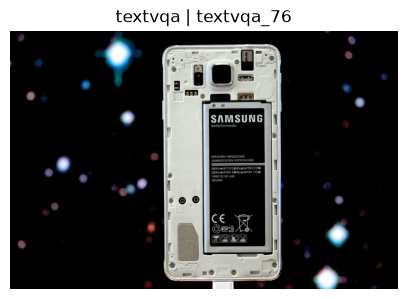

TASK gqa | Sample INDEX 14
Dataset: gqa
Task: gqa
Sample ID: gqa_4
Question: Is there either a black duck or seal?
Answer: no
All answers: ['no']
Metadata: {'raw_index': 4, 'qa_index': 0, 'image_id': '4', 'full_answer': 'No, there is a duck but it is yellow.', 'num_available_qa_pairs': 12}


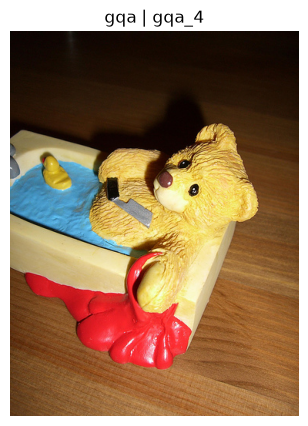

TASK vqav2 | Sample INDEX 3
Dataset: vqav2
Task: vqav2
Sample ID: vqav2_94
Question: What is on the back of the truck?
Answer: lights
All answers: ['lights', 'equipment', 'hose', 'winch', 'fire-fighting equipment', 'tools', 'ladder', 'bumper', 'nothing', 'field']
Metadata: {'raw_index': 94, 'image_id': '363887'}


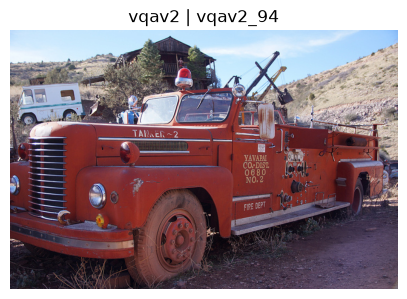

In [5]:
canonical_visualizer = CanonicalDatasetVisualizer(datasets)

canonical_visualizer.preview_sample("textvqa", random.randint(0, len(datasets["textvqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("gqa", random.randint(0, len(datasets["gqa"]) - 1), show_image=True)

canonical_visualizer.preview_sample("vqav2", random.randint(0, len(datasets["vqav2"]) - 1), show_image=True)

In [6]:
serializer = CanonicalDatasetSerializer(datasets)

serialized_datasets = serializer.serialize_datasets()

serializer.save_to_csv(serialized_datasets, global_config["directories"]["results"], "canonical_datasets")

✅ Canonical datasets saved to "/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/outputs/results/canonical_datasets.csv".




In [7]:
from copy import deepcopy
from transformers import AutoImageProcessor

from src.model.config import config as model_config
from src.model.encoder import VisionEncoder

MODEL_CONFIG = deepcopy(model_config)

In [8]:
image_processor = AutoImageProcessor.from_pretrained(MODEL_CONFIG["vision"]["model_name"])

vision_encoder = VisionEncoder(MODEL_CONFIG).to(GLOBAL_CONFIG["device"])

vision_encoder.eval()

print("Device:", GLOBAL_CONFIG["device"])
print("Hidden size:", vision_encoder.hidden_size)
print("Patch grid:", vision_encoder.patch_grid_size)
print("Number of patches:", vision_encoder.number_of_patches)
print("Parameters:", vision_encoder.count_parameters())


Device: mps
Hidden size: 768
Patch grid: (14, 14)
Number of patches: 196
Parameters: {'total': 86389248, 'trainable': 0, 'frozen': 86389248}


In [9]:
sample = datasets[next(iter(datasets))][random.randint(0, len(datasets[next(iter(datasets))]) - 1)]

sample

{'sample_id': 'textvqa_50',
 'dataset': 'textvqa',
 'task': 'textvqa',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=639x1024>,
 'question': 'what is the product designed to be used on?',
 'answer': 'face and body',
 'answers': ['face and body',
  'face and body',
  'witch hazel',
  'face and body',
  'face and body',
  'face & body',
  'for face and body',
  'face and body',
  'face and body',
  'face and body'],
 'metadata': {'raw_index': 50, 'image_id': '97c5ed8eb1005a65'}}

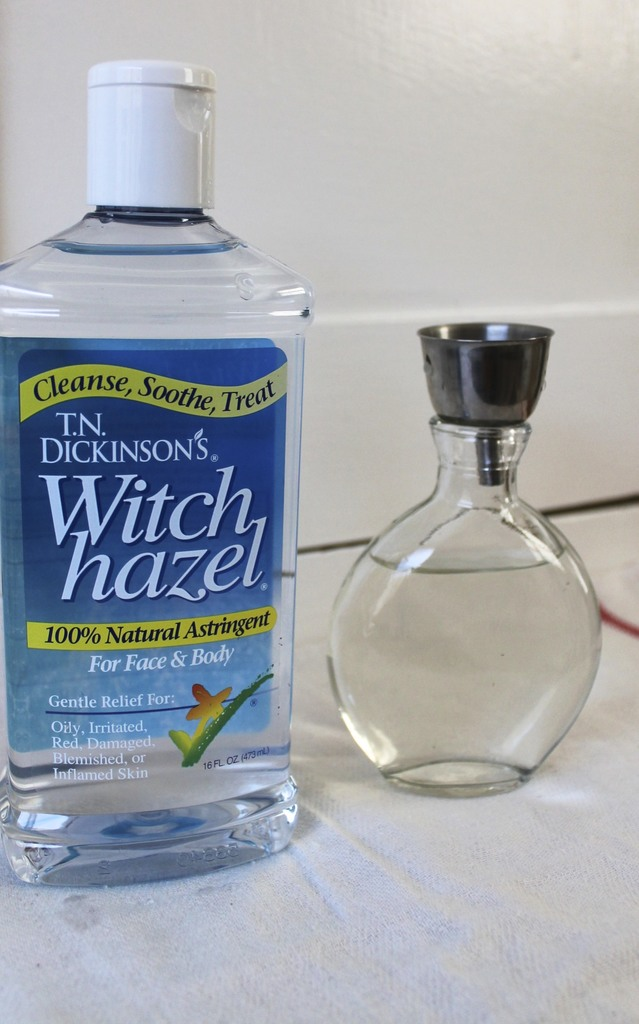

In [10]:
sample_image = sample["image"].convert("RGB")

sample_image

In [11]:
processed_sample = image_processor(images=sample_image, return_tensors="pt")

pixel_values = processed_sample["pixel_values"].to(GLOBAL_CONFIG["device"])

print("Processed image shape:", pixel_values.shape)

Processed image shape: torch.Size([1, 3, 224, 224])


In [12]:
with torch.no_grad():
    output = vision_encoder(pixel_values)
    
print("Patch embeddings:", output.patch_embeddings.shape)
print("CLS embedding:", output.cls_embedding.shape)
print("Attention mask:", output.attention_mask.shape)
print("Patch grid:", output.patch_grid_size)

if output.hidden_states is not None:
    print("Hidden-state stages:", len(output.hidden_states))
    print("Final hidden state:", output.hidden_states[-1].shape)

if output.attentions is not None:
    print("Attention layers:", len(output.attentions))
    print("Final attention:", output.attentions[-1].shape)

Patch embeddings: torch.Size([1, 196, 768])
CLS embedding: torch.Size([1, 768])
Attention mask: torch.Size([1, 196])
Patch grid: (14, 14)
Hidden-state stages: 13
Final hidden state: torch.Size([1, 197, 768])
Attention layers: 12
Final attention: torch.Size([1, 12, 197, 197])


In [13]:
from src.model.encoder import TextEncoder

text_encoder = TextEncoder(MODEL_CONFIG).to(GLOBAL_CONFIG["device"])

text_encoder.eval()

print("Device:", GLOBAL_CONFIG["device"])
print("Hidden size:", text_encoder.hidden_size)
print("Layers:", text_encoder.number_of_layers)
print("Attention heads:", text_encoder.number_of_attention_heads)
print("Parameters:", text_encoder.count_parameters())

[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/ettin-encoder-68m
Key               | Status     |  | 
------------------+------------+--+-
decoder.weight    | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: mps
Hidden size: 512
Layers: 19
Attention heads: 8
Parameters: {'total': 68144640, 'trainable': 0, 'frozen': 68144640}


In [14]:
questions = [
    "What colour is the car?",
    "How many people are standing beside the building?",
]

with torch.no_grad():
    output = text_encoder(
        texts=questions,
        return_tokens=True,
    )

print("Input IDs:", output.input_ids.shape)
print("Attention mask:", output.attention_mask.shape)
print("Token embeddings:", output.token_embeddings.shape)
print("Tokens:", output.tokens)

Input IDs: torch.Size([2, 11])
Attention mask: torch.Size([2, 11])
Token embeddings: torch.Size([2, 11, 512])
Tokens: (('[CLS]', 'What', 'Ġcolour', 'Ġis', 'Ġthe', 'Ġcar', '?', '[SEP]', '[PAD]', '[PAD]', '[PAD]'), ('[CLS]', 'How', 'Ġmany', 'Ġpeople', 'Ġare', 'Ġstanding', 'Ġbeside', 'Ġthe', 'Ġbuilding', '?', '[SEP]'))


In [15]:
# inspect intermediate outputs

if output.hidden_states is not None:
    print("Hidden-state stages:", len(output.hidden_states))
    print(
        "Final hidden state:",
        output.hidden_states[-1].shape,
    )

if output.attentions is not None:
    print("Attention layers:", len(output.attentions))
    print(
        "Final attention:",
        output.attentions[-1].shape,
    )

Hidden-state stages: 20
Final hidden state: torch.Size([2, 11, 512])
Attention layers: 19
Final attention: torch.Size([2, 8, 11, 11])


In [16]:
# inspect tokens without padding

for sample_tokens, sample_mask in zip(
    output.tokens,
    output.attention_mask,
    strict=True,
):
    valid_length = int(sample_mask.sum().item())

    print(sample_tokens[:valid_length])

('[CLS]', 'What', 'Ġcolour', 'Ġis', 'Ġthe', 'Ġcar', '?', '[SEP]')
('[CLS]', 'How', 'Ġmany', 'Ġpeople', 'Ġare', 'Ġstanding', 'Ġbeside', 'Ġthe', 'Ġbuilding', '?', '[SEP]')


In [17]:
from src.model.projection import ModalityProjection

image_projection = ModalityProjection(
    input_size=vision_encoder.hidden_size,
    config=MODEL_CONFIG,
    modality_name="image",
).to(GLOBAL_CONFIG["device"])

text_projection = ModalityProjection(
    input_size=text_encoder.hidden_size,
    config=MODEL_CONFIG,
    modality_name="text",
).to(GLOBAL_CONFIG["device"])

sample_image = sample["image"].convert("RGB")
processed_sample = image_processor(images=sample_image, return_tensors="pt")
pixel_values = processed_sample["pixel_values"].to(GLOBAL_CONFIG["device"])

sample_question = sample["question"]

with torch.no_grad():
    vision_output = vision_encoder(pixel_values)

    text_output = text_encoder(
        texts=sample_question,
        return_tokens=True,
    )

    projected_image = image_projection(
        vision_output.patch_embeddings,
        vision_output.attention_mask,
    )

    projected_text = text_projection(
        text_output.token_embeddings,
        text_output.attention_mask,
    )

print(
    "Raw image:",
    vision_output.patch_embeddings.shape,
)

print(
    "Projected image:",
    projected_image.embeddings.shape,
)

print(
    "Raw text:",
    text_output.token_embeddings.shape,
)

print(
    "Projected text:",
    projected_text.embeddings.shape,
)

Raw image: torch.Size([1, 196, 768])
Projected image: torch.Size([1, 196, 384])
Raw text: torch.Size([1, 12, 512])
Projected text: torch.Size([1, 12, 384])


In [18]:
print(
    "Trainable image encoder parameters:",
    sum(
        parameter.numel()
        for parameter in vision_encoder.parameters()
        if parameter.requires_grad
    ),
)

print(
    "Trainable image projection parameters:",
    sum(
        parameter.numel()
        for parameter in image_projection.parameters()
        if parameter.requires_grad
    ),
)

Trainable image encoder parameters: 0
Trainable image projection parameters: 296064
